In [1]:
import reda
import crtomo

In [2]:
tdip = reda.TDIP()

In [3]:
tdip.import_syscal_bin('data/20181130_01_profil1_normal.bin')
tdip.import_syscal_bin('data/20181130_03_profil2_reziprok.bin', reciprocals=48)
cr = tdip.to_cr()

2025-03-25 08:30:12,362 - reda.containers.BaseContainer  - %INFO       - IRIS Syscal Pro bin import
2025-03-25 08:30:13,701 - reda.containers.BaseContainer  - %INFO       - Data sized changed from 0 to 1460
2025-03-25 08:30:13,702 - reda.containers.BaseContainer  - %INFO       - IRIS Syscal Pro bin import
2025-03-25 08:30:15,215 - reda.containers.BaseContainer  - %INFO       - Data sized changed from 1460 to 2920


In [4]:
cr.data

,a,b,m,n,Iab,Mx,Tm,Vmn,chargeability,mdelay,q,r,vab,rpha,Zt,id,norrec,rdiff,rphadiff
0,1,2,3,4,19.969301,"[24.614469528198242, 19.3248291015625, 16.9280...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-2750.098389,7.724804,40.0,0.044108,-137.716306,177.143951,-11.587206,-137.707061+ 1.595711j,91,nor,-138.181908,-1.201656
1,4,3,2,1,0.157042,"[17.616546630859375, 20.461030960083008, 15.58...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-20.038315,7.772404,40.0,0.261084,-127.598677,2.579252,-11.658606,-127.590005+ 1.487589j,91,rec,-138.181908,-1.201656
2,4,3,1,2,0.159126,"[30.722139358520508, 12.674324035644531, 7.175...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",20.419815,6.065725,40.0,1.155554,128.324591,2.576223,-9.098587,128.319280- 1.167556j,91,rec,-138.181908,-1.201656
3,1,2,3,4,19.320326,"[24.56256675720215, 19.3013916015625, 16.89276...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-2664.690186,7.715533,40.0,0.038719,-137.921596,169.822189,-11.573299,-137.912360+ 1.596172j,91,nor,-138.181908,-1.201656
4,1,2,4,5,19.320326,"[0.23867399990558624, -3.565160036087036, -4.6...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-689.974182,-5.347406,40.0,0.061423,-35.712347,169.822189,8.021110,-35.711198- 0.286450j,123,nor,-35.671810,22.321033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,48,47,45,44,15.861843,"[17.272687911987305, 12.333076477050781, 10.44...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-786.146912,4.017081,40.0,0.051453,-49.562141,196.487259,-6.025622,-49.561242+ 0.298641j,2133,rec,49.611167,2.318527
2917,45,46,47,48,0.143411,"[-2.576369047164917, -19.327594757080078, 31.3...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-16.741514,-0.813032,40.0,1.074848,-116.737743,2.629887,1.219548,-116.737656- 0.142367j,2134,nor,139.265808,0.814490
2918,48,47,46,45,15.861843,"[5.669885635375977, 2.242997884750366, 1.15871...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-2208.266357,0.409969,40.0,0.032342,-139.218774,196.487259,-0.614954,-139.218748+ 0.085613j,2134,rec,139.265808,0.814490
2916,48,47,46,45,17.486357,"[6.521099090576172, 3.2702748775482178, 2.1659...","[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20....",-2440.665527,0.583240,40.0,0.055381,-139.575417,219.969284,-0.874860,-139.575363+ 0.122109j,2134,rec,139.265808,0.814490


In [5]:
cr.compute_K_analytical(spacing=0.25)

array([-4.71238898, -4.71238898,  4.71238898, ..., -4.71238898,
       -4.71238898,  4.71238898])

found duplicate coordinates!
found duplicate coordinates!


(<Figure size 1181.1x787.402 with 2 Axes>,
 <Axes: xlabel='current dipoles', ylabel='voltage dipoles'>,
 <matplotlib.colorbar.Colorbar at 0x7f51cf708c50>)

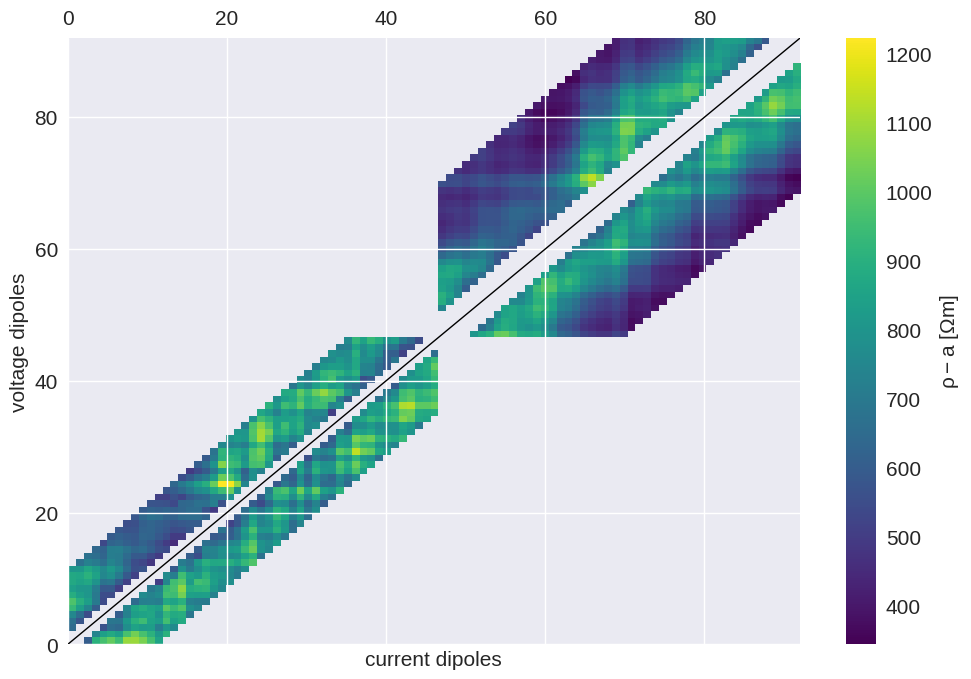

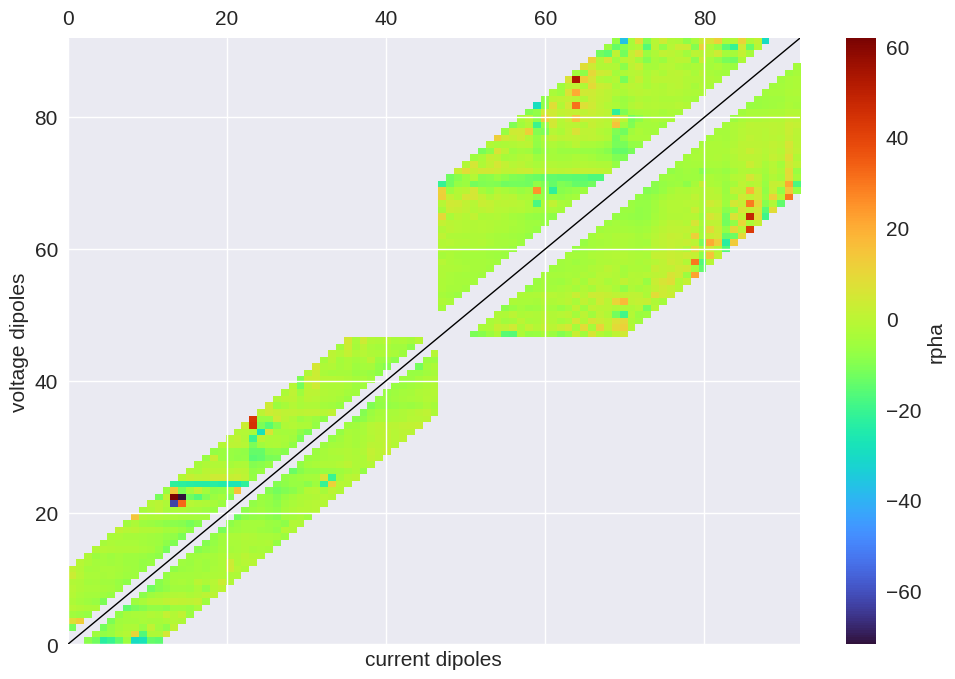

In [6]:
cr.pseudosection_type1(column='rho_a', log10=False)
cr.pseudosection_type1(column='rpha', log10=False, cmap='turbo')

# Filtering

In [7]:
cr.filter('r <= 0')
cr.filter('rpha > 15 or rpha < -50')

2025-03-25 08:30:19,300 - reda.containers.BaseContainer  - %INFO       - Data sized changed from 2920 to 2920
2025-03-25 08:30:21,435 - reda.containers.BaseContainer  - %INFO       - Data sized changed from 2920 to 2894


found duplicate coordinates!


(<Figure size 1181.1x787.402 with 2 Axes>,
 <Axes: xlabel='current dipoles', ylabel='voltage dipoles'>,
 <matplotlib.colorbar.Colorbar at 0x7f51cd0b0710>)

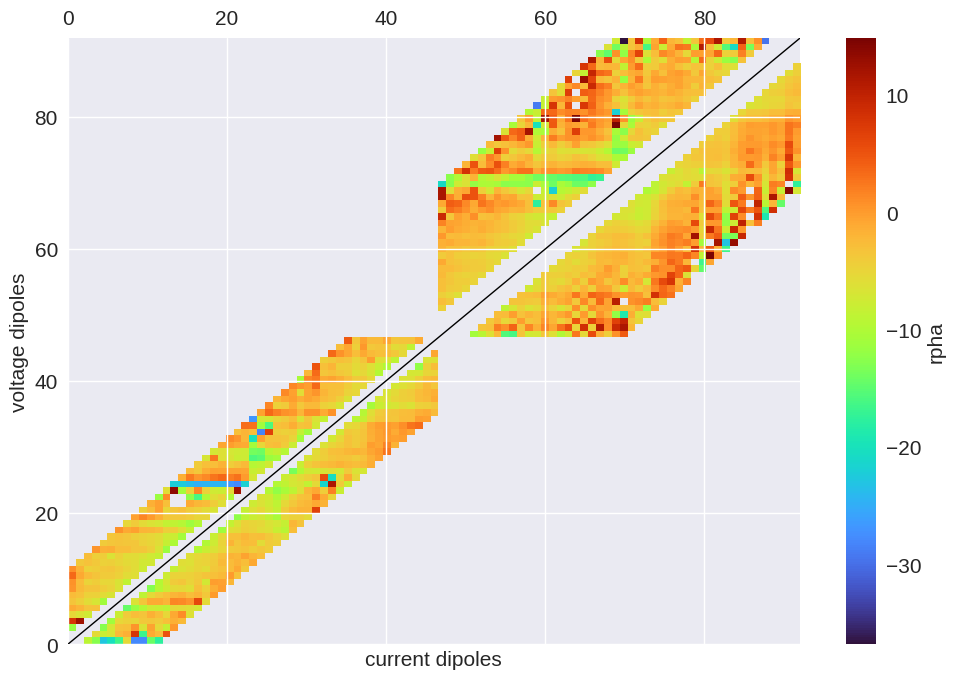

In [8]:
cr.pseudosection_type1(column='rpha', log10=False, cmap='turbo')

# Mesh generation

In [9]:
mesh = crtomo.crt_grid.create_surface_grid(
    nr_electrodes=48,
    spacing=0.25,
    char_lengths=[0.12, 0.8, 0.8, 0.8],
)
print(mesh)

This grid was sorted using CutMcK. The nodes were resorted!
Triangular grid found
CRMod/CTRomo grid instance
number of elements: 2858
number of nodes: 1529
number of electrodes: 48
grid dimsensions: 
X: -2.938 14.688 
Z: -5.875 0.0 



(<Figure size 800x550 with 1 Axes>, <Axes: xlabel='x [m]', ylabel='z [m]'>)

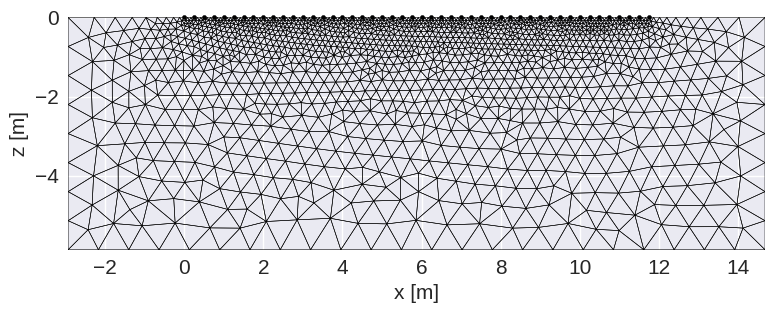

In [10]:
mesh.plot_grid()

In [11]:
tdm = cr.export_to_crtomo_td_manager(
    grid=mesh
)

In [23]:
cr.export_pygimli?

Signature: cr.export_pygimli(electrodes, filename)
Docstring:
Export to unified data format used in pyGIMLi & BERT.

Multiple timesteps are exported to multiple filenames.

Parameters
----------
data : :py:class:`pandas.DataFrame`
    DataFrame with at least a, b, m, n and r.
electrodes : :py:class:`pandas.DataFrame`
    DataFrame with electrode positions.
filename : str
    String of the output filename.
File:      ~/.virtualenvs/crtomo/lib/python3.11/site-packages/reda/exporters/bert.py
Type:      method

In [12]:
tdm.crtomo_cfg

1       !  mswitch
../grid/elem.dat       !  elem
../grid/elec.dat       !  elec
../mod/volt.dat       !  volt
../inv       !  inv_dir
F ! difference inversion?       !  diff_inv

       !  prior_model

iseed variance       !  iseed_var
0    ! # cells in x-direction       !  cells_x
0    ! # cells in z-direction       !  cells_z
1.000  ! smoothing parameter in x-direction       !  ani_x
1.000  ! smoothing parameter in z-direction       !  ani_z
20    ! max. nr of iterations       !  max_it
F     ! DC inversion?       !  dc_inv
T     ! robust inversion?       !  robust_inv
F     ! final phase improvement?       !  fpi_inv
5       !  mag_rel
1e-3       !  mag_abs
0       !  pha_a1
0       !  pha_b
0       !  pha_rel
0       !  pha_abs
F       !  hom_bg
10.00       !  hom_mag
0.00       !  hom_pha
F       !  another_ds
1       !  d2_5
F       !  fic_sink
10000       !  fic_sink_node
F       !  boundaries
boundary.dat       !  boundaries_file
1       !  mswitch2
lambda       !  lambda

In [13]:
tdm.crtomo_cfg['cells_z'] = -1

In [14]:
tdm.invert(cores=2, catch_output=False)

Attempting inversion in directory: /tmp/tmpw88vnlsv
Using binary: /home/mweigand/bin/CRTomo
Calling CRTomo
 ######### CRTomo ############
Licence:
Copyright © 1990-2020 Andreas Kemna <kemna@geo.uni-bonn.de>
Copyright © 2008-2020 CRTomo development team (see AUTHORS file)
Permission is hereby granted, free of charge, to any person obtaining a copy of
this software and associated documentation files (the “Software”), to deal in
the Software without restriction, including without limitation the rights to
use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies
of the Software, and to permit persons to whom the Software is furnished to do
so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PART

Note: The following floating-point exceptions are signalling: IEEE_DIVIDE_BY_ZERO
STOP 0


Statistics of last iteration:
iteration              9
main_iteration         9
it_type            DC/IP
type                main
dataRMS           0.9826
magRMS               3.0
phaRMS               2.0
lambda             29.37
roughness           24.7
cgsteps              4.0
nrdata            2891.0
steplength           4.0
stepsize           40.87
l1ratio              8.0
Name: 99, dtype: object


0

(<Figure size 629.921x314.961 with 2 Axes>,
 <Axes: xlabel='x [m]', ylabel='z [m]'>)

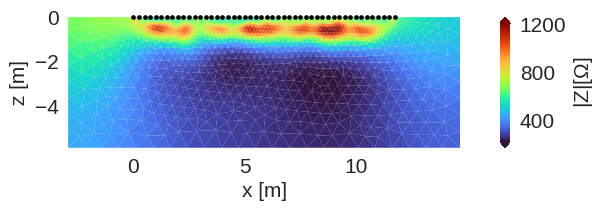

In [15]:
tdm.plot_inversion_result_rmag()

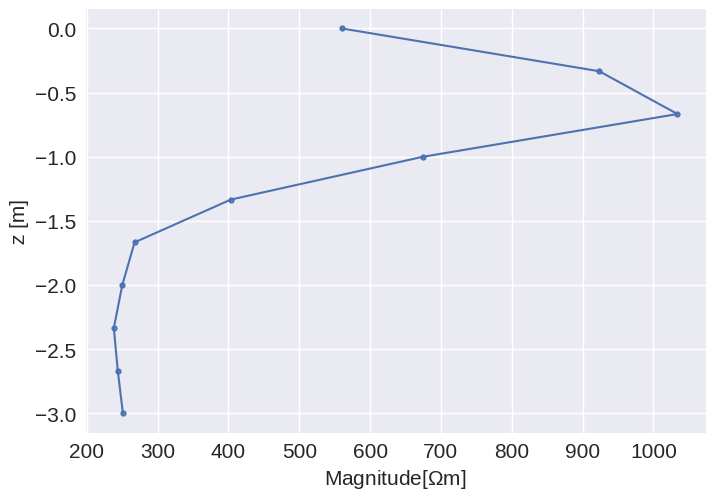

In [21]:
extraction = tdm.extract_along_line(
    tdm.a['inversion']['rmag'][-1],
    [5, 0],
    [5, -3],
)
import matplotlib.pylab as plt
fig, ax = plt.subplots()
ax.plot(
    extraction[:, 2],
    extraction[:, 1],
    '.-',
)
ax.set_xlabel(r'$Magnitude [\Omega m]$')
_ = ax.set_ylabel('z [m]')
